# Sales Forecasting & Demand Intelligence System

**Name:** Guttula Samuel

**Submission Date:** 13-07-2026


# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')  # sklearn/statsmodels throw a lot of harmless warnings, muting them for readability

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


# Load Dataset


In [2]:
df = pd.read_csv('train.csv')
print("Rows, Columns:", df.shape)
df.head()


Rows, Columns: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Data Understanding

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.describe()


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values per column:
Postal Code    11
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Unique Categories:", df['Category'].unique())
print("Unique Regions:", df['Region'].unique())
print("Unique Segments:", df['Segment'].unique())
print("Date range (raw, still text):", df['Order Date'].min(), "to", df['Order Date'].max())


Duplicate rows: 0

Unique Categories: ['Furniture' 'Office Supplies' 'Technology']
Unique Regions: ['South' 'West' 'Central' 'East']
Unique Segments: ['Consumer' 'Corporate' 'Home Office']
Date range (raw, still text): 01/01/2018 to 31/12/2017


# Task 1 - Data Loading, Merging & Deep Exploration


### Fixing the date columns

In [7]:
# The dates in this CSV are written as DD/MM/YYYY, not the usual MM/DD/YYYY.
# I figured this out by checking a few rows - for example one row had order date
# 16/06/2017, and 16 obviously can't be a month, so it has to be day/month/year.
# If we don't set dayfirst=True here, pandas will silently parse a bunch of dates
# wrong without throwing any error, which is worse than an actual crash.

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print(df[['Order Date', 'Ship Date']].dtypes)
print("Now the date range makes sense:", df['Order Date'].min(), "to", df['Order Date'].max())


Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object
Now the date range makes sense: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


### Creating time-based columns

In [8]:
# breaking the order date down into pieces we'll need later for grouping / features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week Number'] = df['Order Date'].dt.isocalendar().week
df['Day of Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

# pandas doesn't have a built-in "season" thing, so writing a small function for it
# assuming standard US seasons since this is US retail data
def get_season(month_num):
    if month_num in (12, 1, 2):
        return 'Winter'
    elif month_num in (3, 4, 5):
        return 'Spring'
    elif month_num in (6, 7, 8):
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

df[['Order Date', 'Year', 'Month', 'Week Number', 'Day of Week', 'Quarter', 'Season']].head()


,Order Date,Year,Month,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Fall
1,2017-11-08,2017,11,45,Wednesday,4,Fall
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Fall
4,2016-10-11,2016,10,41,Tuesday,4,Fall


### Checking data quality again 

In [9]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types now:")
print(df.dtypes)


Missing values:
Postal Code    11
dtype: int64



Duplicate rows: 0

Data types now:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week Number              UInt32
Day of Week              object
Quarter                   int32
Season                   object
dtype: object


In [10]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

bad_rows = (df['Shipping Days'] < 0).sum()
print("Orders where Ship Date is before Order Date:", bad_rows)


Orders where Ship Date is before Order Date: 0


### Aggregating sales into weekly and monthly totals

In [11]:
# right now every row is one order line item, so multiple rows can have the same date.
# to actually treat this as a time series we need to group by date and add up sales.

weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

print("Weekly data points:", len(weekly_sales))
print("Monthly data points:", len(monthly_sales))

monthly_sales.head()


Weekly data points: 209
Monthly data points: 48


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


###  Answering the business questions

**Q1: Which product category generates the highest total revenue?**

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


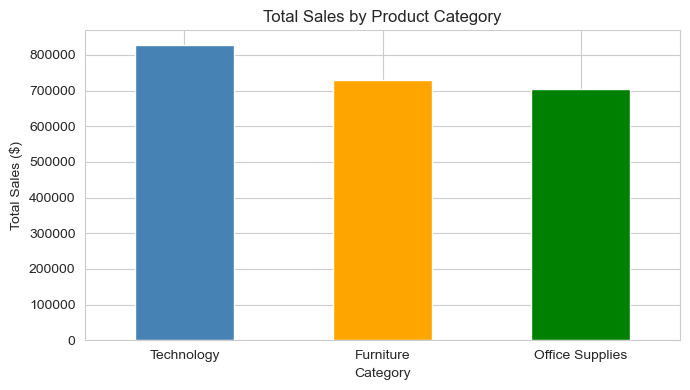

In [12]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)

plt.figure(figsize=(7, 4))
category_revenue.plot(kind='bar', color=['steelblue', 'orange', 'green'])
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/task1_category_revenue.png')
plt.show()


**Q2: Which region has the most consistent sales growth over the 4 years?**

In [13]:
region_year = df.groupby(['Year', 'Region'])['Sales'].sum().unstack()
print(region_year)

# calculating year over year % growth instead of raw dollar difference,
# because % growth lets us compare regions fairly even if their total sales are different sizes
region_growth = region_year.pct_change().dropna() * 100
print("\nYear over year growth %:")
print(region_growth.round(1))


Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

Year over year growth %:
Region  Central  East  South  West
Year                              
2016       -0.5  20.0  -32.2  -8.4
2017       42.2  16.5   33.5  36.5
2018       -2.8  17.7   30.6  36.0


Standard deviation of growth % (lower = more consistent):
Region
East        1.79
Central    25.35
West       25.74
South      37.12
dtype: float64


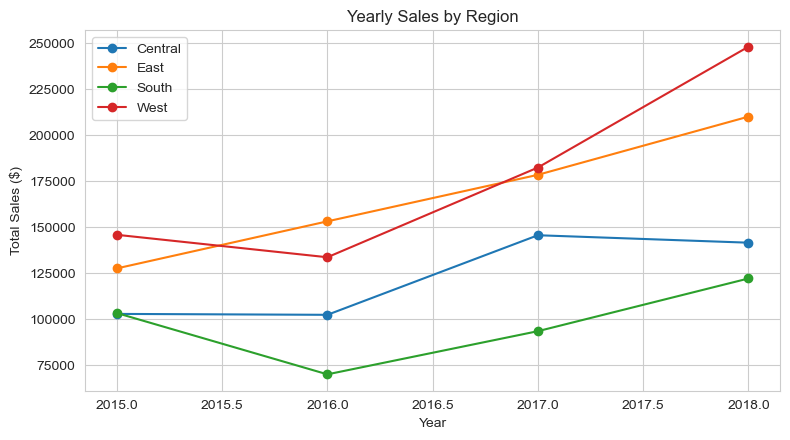

In [14]:
# "most consistent" to me means the growth rate doesn't swing around too much year to year
# so using standard deviation of the growth % - lower std = more stable/consistent growth
growth_consistency = region_growth.std().sort_values()
print("Standard deviation of growth % (lower = more consistent):")
print(growth_consistency.round(2))

plt.figure(figsize=(8, 4.5))
for region in region_year.columns:
    plt.plot(region_year.index, region_year[region], marker='o', label=region)
plt.title('Yearly Sales by Region')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task1_region_growth.png')
plt.show()


**Q3: What is the average time between Order Date and Ship Date, and does it vary by region?**

Overall average shipping time: 3.96 days

Average shipping time by region:
Region
East       3.91
West       3.93
South      3.96
Central    4.07
Name: Shipping Days, dtype: float64


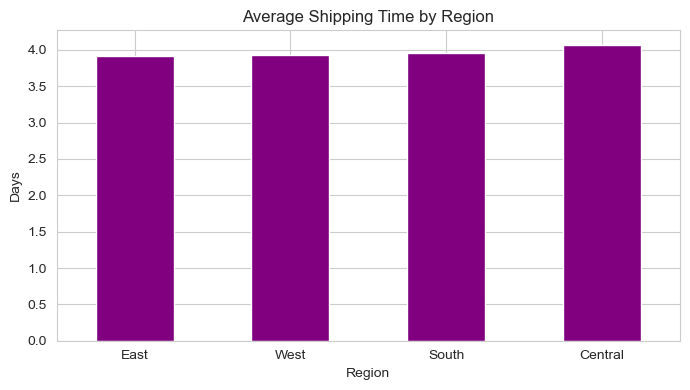

In [15]:
avg_shipping = df['Shipping Days'].mean()
print("Overall average shipping time:", round(avg_shipping, 2), "days")

shipping_region = df.groupby('Region')['Shipping Days'].mean().sort_values()
print("\nAverage shipping time by region:")
print(shipping_region.round(2))

plt.figure(figsize=(7, 4))
shipping_region.plot(kind='bar', color='purple')
plt.title('Average Shipping Time by Region')
plt.xlabel('Region')
plt.ylabel('Days')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/task1_shipping_by_region.png')
plt.show()


**Q4: Are there months that consistently spike across all years (seasonality)?**

In [16]:
month_totals = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
print(month_totals)


Month
11    350161.7110
12    321480.1695
9     300103.4117
10    199496.2947
3     197573.5872
8     157315.9270
5     154086.7237
6     145837.5233
7     145535.6890
4     136283.0006
1      94291.6296
2      59371.1154
Name: Sales, dtype: float64


In [17]:
year_month = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# for every year, get the top 3 months by sales
top3_per_year = year_month.sort_values(['Year', 'Sales'], ascending=[True, False]).groupby('Year').head(3)
print(top3_per_year)

# now count how many times each month shows up in a year's top 3 (max would be 4, since we have 4 years)
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
top3_per_year['MonthName'] = top3_per_year['Month'].map(month_names)
print("\nHow many times each month appears in top 3 across the 4 years:")
print(top3_per_year['MonthName'].value_counts())


    Year  Month        Sales
8   2015      9   81623.5268
10  2015     11   77907.6607
11  2015     12   68167.0585
22  2016     11   75249.3995
23  2016     12   74543.6012
20  2016      9   63133.6060
35  2017     12   95739.1210
34  2017     11   79066.4958
32  2017      9   69193.3909
46  2018     11  117938.1550
44  2018      9   86152.8880
47  2018     12   83030.3888

How many times each month appears in top 3 across the 4 years:
MonthName
Sep    4
Nov    4
Dec    4
Name: count, dtype: int64


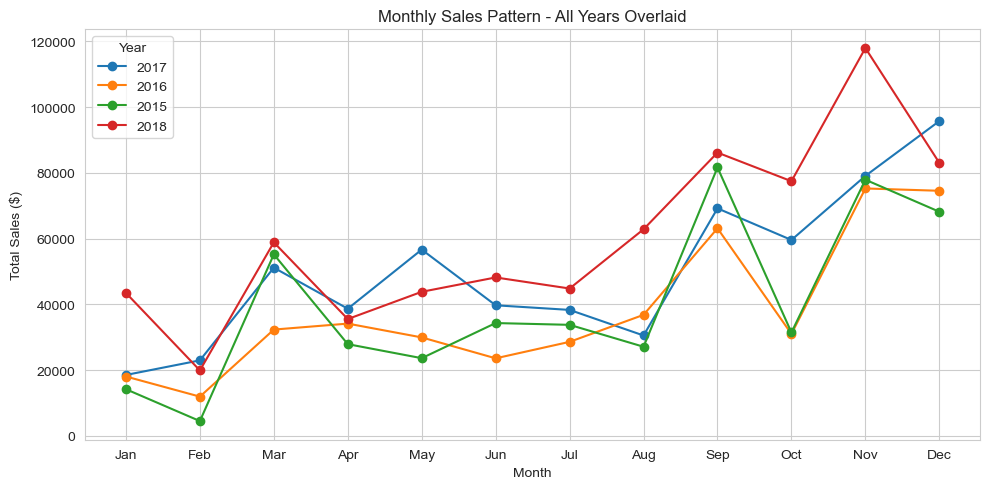

In [18]:
plt.figure(figsize=(10, 5))
for year in df['Year'].unique():
    yearly = df[df['Year'] == year].groupby('Month')['Sales'].sum()
    plt.plot(yearly.index, yearly.values, marker='o', label=str(year))
plt.title('Monthly Sales Pattern - All Years Overlaid')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1, 13), [month_names[m] for m in range(1, 13)])
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('charts/task1_seasonality.png')
plt.show()


## Results
- Highest revenue category: **Technology** (~\$827K, about 37% of total sales)
- Most consistent growing region: **East** (lowest year-to-year growth variability)
- Average shipping time: **~4 days**, doesn't really change much by region
- Reliable seasonal spike months: **September, November, December** (appear in top-3 every year)

# Task 2 - Time Series Analysis & Decomposition


### Getting the monthly series ready

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# rebuilding monthly_sales as a proper time-indexed series (with Order Date as the index)
# instead of two separate columns, statsmodels wants it this way
monthly_ts = df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum()
monthly_ts = monthly_ts.asfreq('MS')  # making sure there's no gap in months

print(monthly_ts.head())
print("\nTotal months:", len(monthly_ts))


Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

Total months: 48


### Plotting the overall trend first

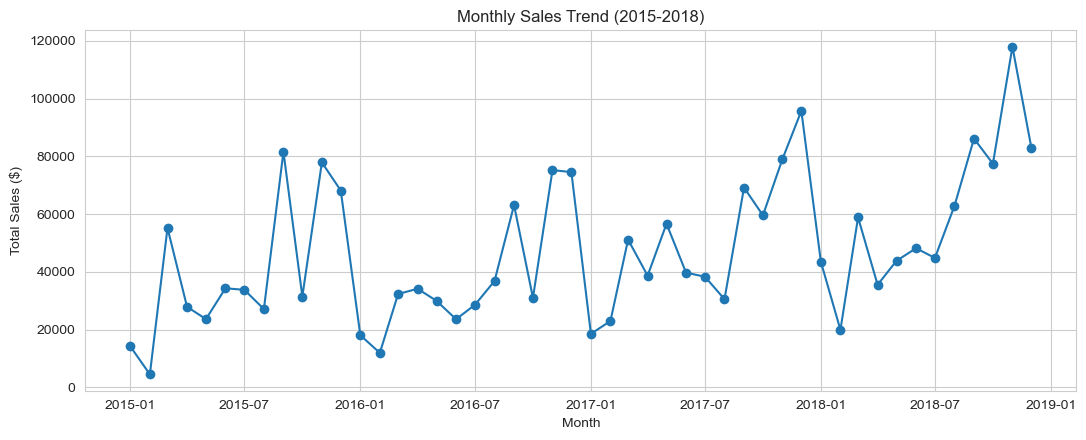

In [20]:
plt.figure(figsize=(11, 4.5))
plt.plot(monthly_ts.index, monthly_ts.values, marker='o')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/task2_monthly_trend.png')
plt.show()


### Decomposition

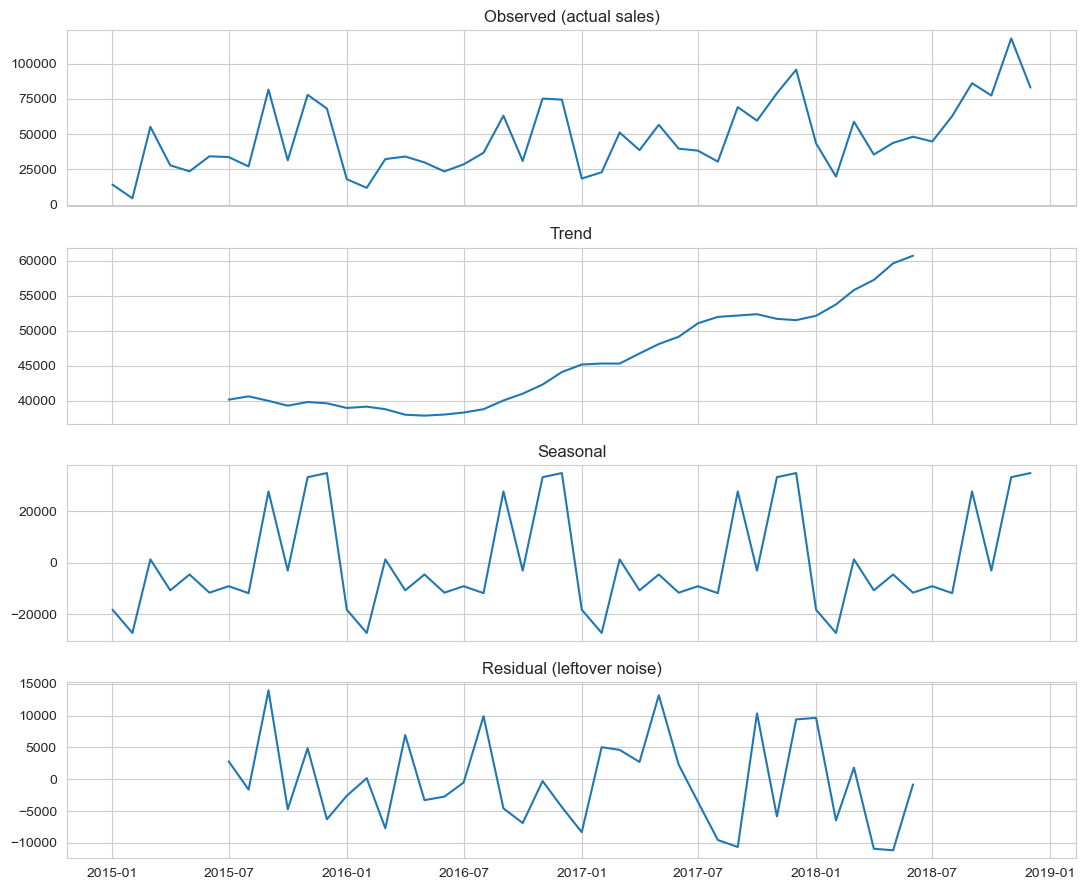

In [21]:
# period=12 because we're assuming a yearly repeating pattern (12 months),
# which matches what we already found in Task 1
decomposition = seasonal_decompose(monthly_ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

axes[0].plot(decomposition.observed)
axes[0].set_title('Observed (actual sales)')

axes[1].plot(decomposition.trend)
axes[1].set_title('Trend')

axes[2].plot(decomposition.seasonal)
axes[2].set_title('Seasonal')

axes[3].plot(decomposition.resid)
axes[3].set_title('Residual (leftover noise)')

plt.tight_layout()
plt.savefig('charts/task2_decomposition.png')
plt.show()


Looking at the 4 charts:
- **Trend** - there's a clear upward trend, sales are generally growing year over year, not just staying flat.
- **Seasonal** - this repeats the same shape every 12 months which confirms what we suspected - there IS a real seasonal pattern, it's not random.
- **Residual** - this is the "leftover" after removing trend and seasonality. It looks mostly random/scattered around zero which is what you want to see, but it does get a bit bigger around the Nov/Dec area, meaning our simple decomposition doesn't perfectly capture how big the holiday spike will be every single year - the exact size is harder to predict than just knowing "Nov/Dec will be high."


### Checking for stationarity (ADF Test)

In [22]:
result = adfuller(monthly_ts)
print("ADF Statistic:", round(result[0], 4))
print("p-value:", round(result[1], 6))

if result[1] < 0.05:
    print("=> This looks stationary (p-value is below 0.05)")
else:
    print("=> This does NOT look stationary")


ADF Statistic: -4.4161
p-value: 0.000278
=> This looks stationary (p-value is below 0.05)


### Differencing 

After differencing:
ADF Statistic: -8.7271
p-value: 0.0


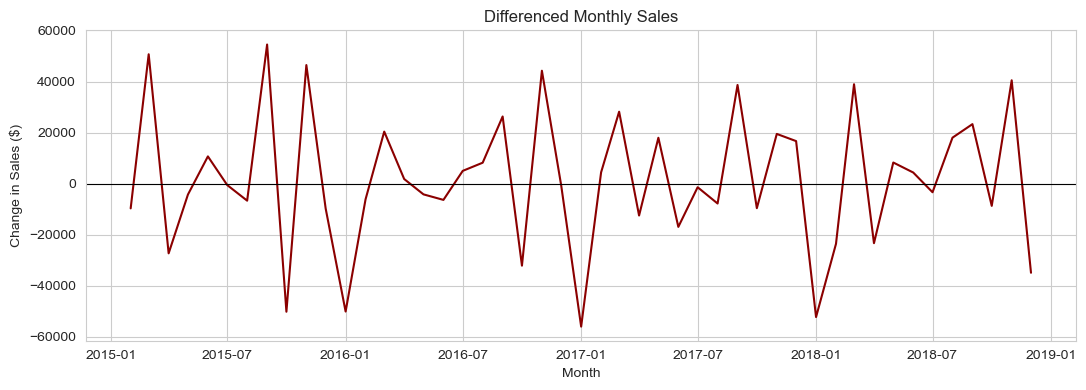

In [23]:
# differencing = subtracting each value from the one before it
# this is a common trick to remove trend and help make a series more stationary
monthly_diff = monthly_ts.diff().dropna()

result_diff = adfuller(monthly_diff)
print("After differencing:")
print("ADF Statistic:", round(result_diff[0], 4))
print("p-value:", round(result_diff[1], 8))

plt.figure(figsize=(11, 4))
plt.plot(monthly_diff.index, monthly_diff.values, color='darkred')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Differenced Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Change in Sales ($)')
plt.tight_layout()
plt.savefig('charts/task2_differenced.png')
plt.show()


# Task 3 - Sales Forecasting using 3 Different Models



In [24]:
train_data = monthly_ts[:-3]
test_data = monthly_ts[-3:]

print("Training on", len(train_data), "months")
print("Testing on:")
print(test_data)


Training on 45 months
Testing on:
Order Date
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Freq: MS, Name: Sales, dtype: float64


## Model 1 - SARIMA

SARIMA is chosen because it's basically built for exactly this kind of problem - a time series with both trend and seasonality, which is exactly what we found in Task 2. It's a classic statistics-based approach, not machine learning.

**Why this model:** it directly models trend + seasonality + the ups and downs, and it's a pretty standard choice for monthly retail sales.

**Advantages:** gives us confidence intervals automatically, well understood and explainable to non-technical people.

**Limitations:** need to pick the right (p,d,q)(P,D,Q,m) parameters which honestly involves a bit of trial and error, and it can struggle if there isn't enough historical data.

**Choosing the parameters:** since Task 2 showed we needed 1 round of differencing to get stationary (d=1), and we have yearly seasonality (m=12, so D=1 for seasonal differencing too), I went with a fairly standard starting combination of p=1, q=1, P=1, Q=1. This isn't from a full grid search - a more thorough approach would try a bunch of combinations and pick whichever gives the lowest AIC, but given the time we have I just went with commonly-recommended defaults for monthly retail data.

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

sarima_model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

print(sarima_pred)


2018-10-01    60331.792101
2018-11-01    91458.220223
2018-12-01    97167.570949
Freq: MS, Name: predicted_mean, dtype: float64


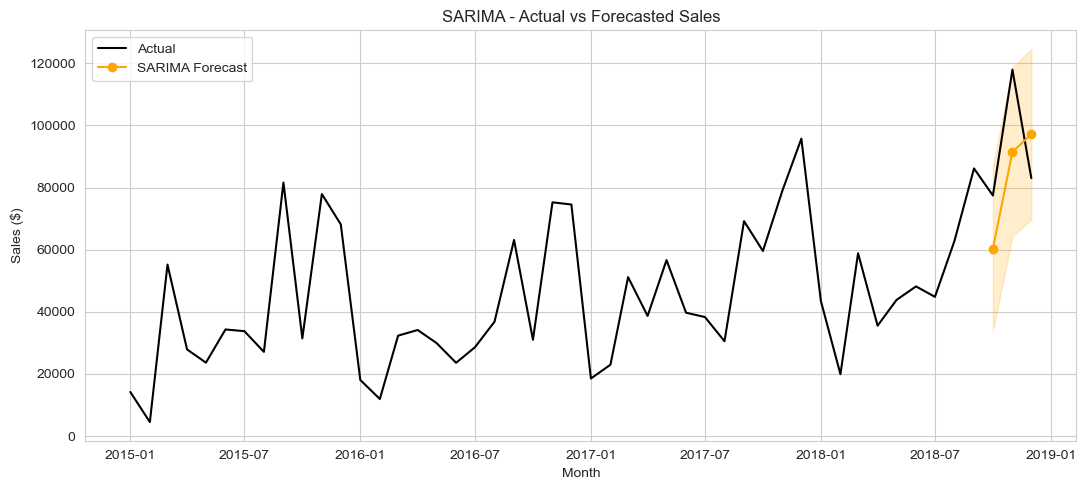

SARIMA MAE: 19244  RMSE: 19950  MAPE: 20.5%


In [26]:
plt.figure(figsize=(11, 5))
plt.plot(monthly_ts.index, monthly_ts.values, label='Actual', color='black')
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA Forecast', color='orange', marker='o')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='orange', alpha=0.2)
plt.title('SARIMA - Actual vs Forecasted Sales')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task3_sarima.png')
plt.show()

sarima_mae = mean_absolute_error(test_data, sarima_pred)
sarima_rmse = mean_squared_error(test_data, sarima_pred) ** 0.5
sarima_mape = (abs((test_data.values - sarima_pred.values) / test_data.values)).mean() * 100
print(f"SARIMA MAE: {sarima_mae:.0f}  RMSE: {sarima_rmse:.0f}  MAPE: {sarima_mape:.1f}%")


## Model 2 - Facebook Prophet

**Why this model:** Prophet is basically the industry-standard "just works out of the box" forecasting tool, made by Facebook specifically for business-type time series like this. Good to compare against SARIMA since it takes a different mathematical approach (curve-fitting based rather than the ARIMA statistics approach).

**Advantages:** handles seasonality automatically without needing us to manually pick parameters like SARIMA does, and gives a nice breakdown of trend vs seasonality.

**Limitations:** can be a bit of a "black box" compared to SARIMA - less control over the exact model structure, and it sometimes needs a decent amount of data to detect seasonality reliably.

In [27]:
from prophet import Prophet

# Prophet needs the data in a specific format - columns must be named 'ds' and 'y'
prophet_data = monthly_ts.reset_index()
prophet_data.columns = ['ds', 'y']

prophet_train = prophet_data.iloc[:-3]
prophet_test = prophet_data.iloc[-3:]

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future_dates = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future_dates)

prophet_pred = prophet_forecast.set_index('ds')['yhat'].iloc[-3:]
print(prophet_pred)


18:39:05 - cmdstanpy - INFO - Chain [1] start processing
18:39:06 - cmdstanpy - INFO - Chain [1] done processing


ds
2018-10-01    51083.663771
2018-11-01    90045.402120
2018-12-01    89661.190723
Name: yhat, dtype: float64


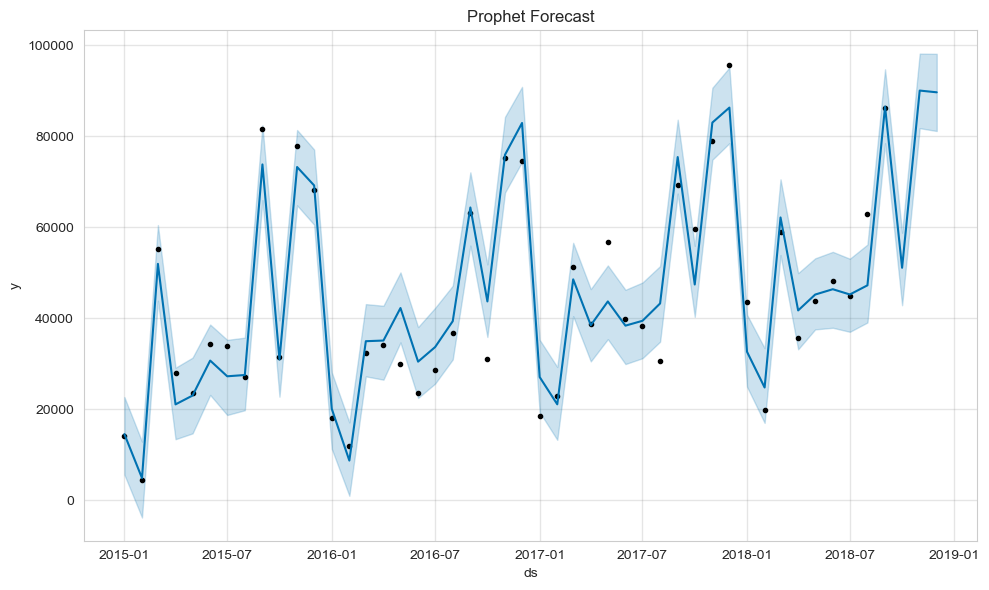

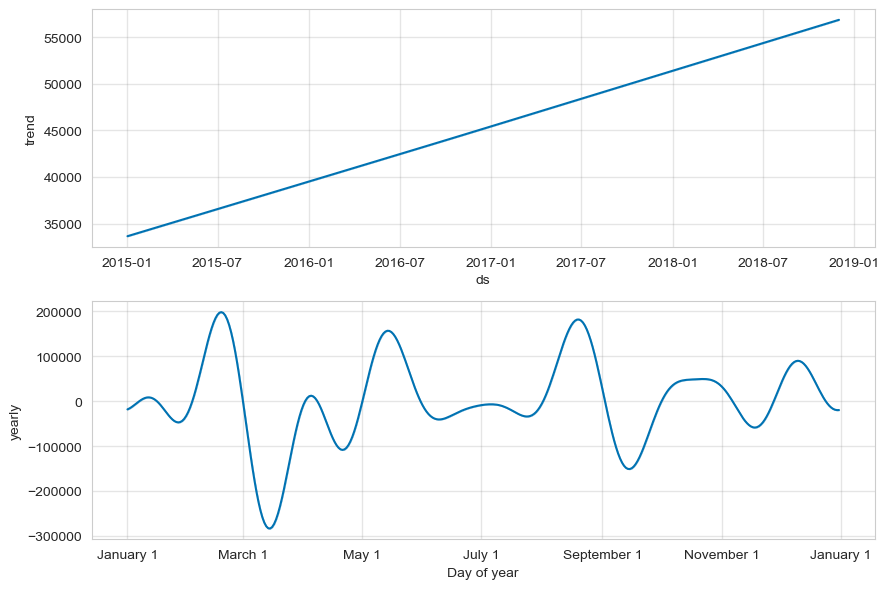

In [28]:
fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.tight_layout()
plt.savefig('charts/task3_prophet_forecast.png')
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.savefig('charts/task3_prophet_components.png')
plt.show()


In [29]:
prophet_mae = mean_absolute_error(prophet_test['y'], prophet_pred.values)
prophet_rmse = mean_squared_error(prophet_test['y'], prophet_pred.values) ** 0.5
prophet_mape = (abs((prophet_test['y'].values - prophet_pred.values) / prophet_test['y'].values)).mean() * 100
print(f"Prophet MAE: {prophet_mae:.0f}  RMSE: {prophet_rmse:.0f}  MAPE: {prophet_mape:.1f}%")


Prophet MAE: 20296  RMSE: 22487  MAPE: 21.9%


## Model 3 - XGBoost

**Why this model:** wanted to try a completely different approach - actual machine learning instead of a "statistical time series" model. XGBoost doesn't understand dates or time on its own though, so we have to trick it a bit by turning the time series into a normal table of features and a target, using past months' sales as input features (this is called "lag features").

**Advantages:** can pick up on non-linear patterns that SARIMA/Prophet might miss, and can easily use extra features later if we had things like promotions or pricing data.

**Limitations:** doesn't understand "time" natively so needs manual feature engineering, and with only 48 months of data there isn't a huge amount to train on for a model like this.

In [30]:
ml_data = monthly_ts.reset_index()
ml_data.columns = ['Date', 'Sales']

ml_data['Month'] = ml_data['Date'].dt.month
ml_data['Quarter'] = ml_data['Date'].dt.quarter
ml_data['Season_num'] = ml_data['Month'].apply(lambda m: (m % 12) // 3)

# lag features - sales from 1, 2, 3 months ago
ml_data['lag1'] = ml_data['Sales'].shift(1)
ml_data['lag2'] = ml_data['Sales'].shift(2)
ml_data['lag3'] = ml_data['Sales'].shift(3)
ml_data['roll_mean3'] = ml_data['Sales'].shift(1).rolling(3).mean()

# first 3 rows will have NaN lags since there's no "3 months ago" data yet, dropping those
ml_data = ml_data.dropna().reset_index(drop=True)

feature_cols = ['lag1', 'lag2', 'lag3', 'roll_mean3', 'Month', 'Quarter', 'Season_num']
ml_train = ml_data.iloc[:-3]
ml_test = ml_data.iloc[-3:]

ml_data.tail()


,Date,Sales,Month,Quarter,Season_num,lag1,lag2,lag3,roll_mean3
40,2018-08-01,62837.8480,8,3,2,44825.1040,48190.7277,43825.9822,45613.937967
41,2018-09-01,86152.8880,9,3,3,62837.8480,44825.1040,48190.7277,51951.226567
42,2018-10-01,77448.1312,10,4,3,86152.8880,62837.8480,44825.1040,64605.280000
43,2018-11-01,117938.1550,11,4,3,77448.1312,86152.8880,62837.8480,75479.622400
44,2018-12-01,83030.3888,12,4,0,117938.1550,77448.1312,86152.8880,93846.391400


In [31]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(ml_train[feature_cols], ml_train['Sales'])

xgb_pred = xgb_model.predict(ml_test[feature_cols])
print("Predicted:", xgb_pred)
print("Actual:", ml_test['Sales'].values)


ModuleNotFoundError: No module named 'xgboost'

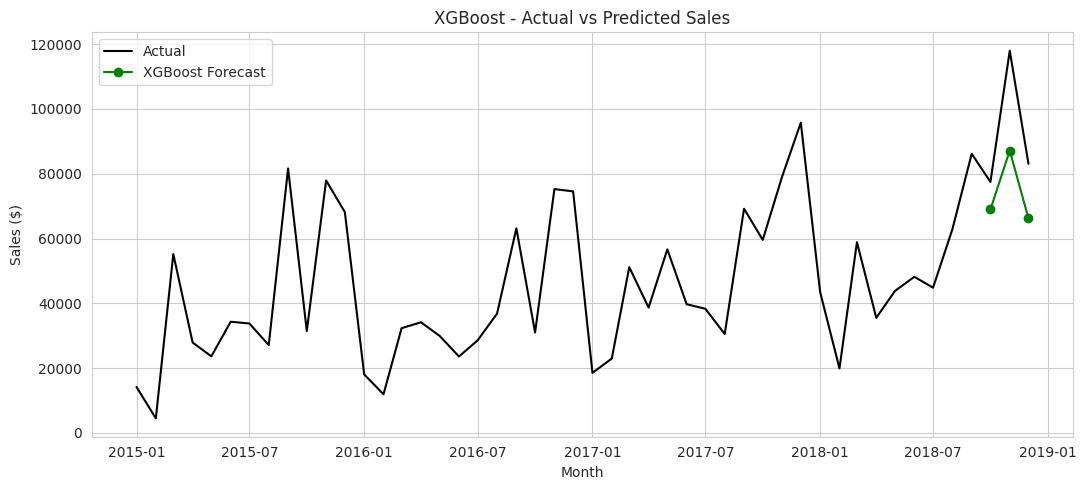

XGBoost MAE: 18710  RMSE: 20853  MAPE: 19.1%


In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(monthly_ts.index, monthly_ts.values, label='Actual', color='black')
plt.plot(ml_test['Date'], xgb_pred, label='XGBoost Forecast', color='green', marker='o')
plt.title('XGBoost - Actual vs Predicted Sales')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task3_xgboost.png')
plt.show()

xgb_mae = mean_absolute_error(ml_test['Sales'], xgb_pred)
xgb_rmse = mean_squared_error(ml_test['Sales'], xgb_pred) ** 0.5
xgb_mape = (abs((ml_test['Sales'].values - xgb_pred) / ml_test['Sales'].values)).mean() * 100
print(f"XGBoost MAE: {xgb_mae:.0f}  RMSE: {xgb_rmse:.0f}  MAPE: {xgb_mape:.1f}%")


## Model Comparison

In [ ]:
comparison_table = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [round(sarima_mae), round(prophet_mae), round(xgb_mae)],
    'RMSE': [round(sarima_rmse), round(prophet_rmse), round(xgb_rmse)],
    'MAPE (%)': [round(sarima_mape, 1), round(prophet_mape, 1), round(xgb_mape, 1)],
    'Forecast Month 1': [round(sarima_pred.values[0]), round(prophet_pred.values[0]), round(xgb_pred[0])],
    'Forecast Month 2': [round(sarima_pred.values[1]), round(prophet_pred.values[1]), round(xgb_pred[1])],
    'Forecast Month 3': [round(sarima_pred.values[2]), round(prophet_pred.values[2]), round(xgb_pred[2])],
})
comparison_table


,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244,19950,20.5,60332,91458,97168
1,Prophet,20296,22487,21.9,51084,90045,89661
2,XGBoost,18710,20853,19.1,68953,87130,66202


# Task 4 - Product Category & Region Level Forecasting


In [ ]:
def get_monthly_for(column_name, value):
    """Filters the dataframe to one category/region and returns its monthly sales series."""
    filtered = df[df[column_name] == value]
    monthly = filtered.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum()
    return monthly.asfreq('MS', fill_value=0)


def forecast_with_xgboost(series, steps=3):
    """Same lag-feature approach as Task 3, just wrapped in a function so we can reuse it
    for every category/region instead of copy-pasting the code 5 times."""
    data = series.reset_index()
    data.columns = ['Date', 'Sales']
    data['Month'] = data['Date'].dt.month
    data['Quarter'] = data['Date'].dt.quarter
    data['Season_num'] = data['Month'].apply(lambda m: (m % 12) // 3)
    data['lag1'] = data['Sales'].shift(1)
    data['lag2'] = data['Sales'].shift(2)
    data['lag3'] = data['Sales'].shift(3)
    data['roll_mean3'] = data['Sales'].shift(1).rolling(3).mean()
    data = data.dropna().reset_index(drop=True)

    cols = ['lag1', 'lag2', 'lag3', 'roll_mean3', 'Month', 'Quarter', 'Season_num']
    train_part = data.iloc[:-steps]
    test_part = data.iloc[-steps:]

    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(train_part[cols], train_part['Sales'])
    predictions = model.predict(test_part[cols])

    return test_part['Date'].values, predictions, test_part['Sales'].values, data.set_index('Date')['Sales']


In [ ]:
segments_to_forecast = {
    'Furniture': ('Category', 'Furniture'),
    'Technology': ('Category', 'Technology'),
    'Office Supplies': ('Category', 'Office Supplies'),
    'West': ('Region', 'West'),
    'East': ('Region', 'East'),
}

segment_results = {}

for segment_name, (col, val) in segments_to_forecast.items():
    monthly_series = get_monthly_for(col, val)
    dates, preds, actuals, full_history = forecast_with_xgboost(monthly_series)
    segment_results[segment_name] = {
        'dates': dates, 'preds': preds, 'actuals': actuals, 'history': full_history
    }
    seg_mape = (abs((actuals - preds) / actuals)).mean() * 100
    print(f"{segment_name:16s} Month1: {preds[0]:>9,.0f}  Month2: {preds[1]:>9,.0f}  "
          f"Month3: {preds[2]:>9,.0f}   MAPE: {seg_mape:.1f}%")


Furniture        Month1:    13,578  Month2:    29,892  Month3:    33,018   MAPE: 20.8%


Technology       Month1:    22,948  Month2:    26,856  Month3:    22,559   MAPE: 26.1%
Office Supplies  Month1:    24,838  Month2:    27,293  Month3:    29,313   MAPE: 7.9%


West             Month1:    25,108  Month2:    25,863  Month3:    29,916   MAPE: 9.7%


East             Month1:    17,566  Month2:    28,656  Month3:    29,373   MAPE: 45.0%


### All 5 forecasts plotted together

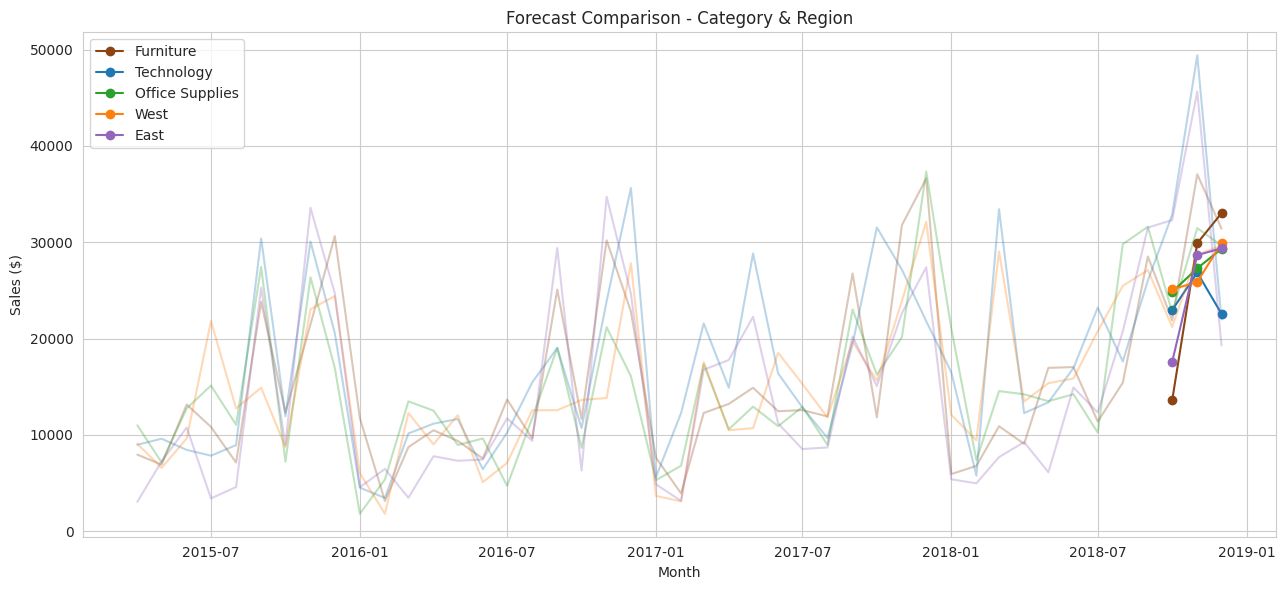

In [ ]:
plt.figure(figsize=(13, 6))
color_list = ['#8B4513', '#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']

for (seg_name, res), color in zip(segment_results.items(), color_list):
    plt.plot(res['history'].index, res['history'].values, color=color, alpha=0.3)
    plt.plot(res['dates'], res['preds'], color=color, marker='o', label=seg_name)

plt.title('Forecast Comparison - Category & Region')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task4_segment_comparison.png')
plt.show()


In [ ]:
# checking which segment is growing the fastest heading into month 3 of the forecast
growth_check = {}
for seg_name, res in segment_results.items():
    baseline = res['history'].iloc[-4]  # last known real value before the forecast window
    forecasted_month3 = res['preds'][-1]
    pct_change = (forecasted_month3 - baseline) / baseline * 100
    growth_check[seg_name] = round(pct_change, 1)

growth_series = pd.Series(growth_check).sort_values(ascending=False)
print("Projected % change by month 3 of forecast:")
print(growth_series)


Projected % change by month 3 of forecast:
Furniture          15.8
West               10.4
East               -6.8
Office Supplies    -7.3
Technology        -13.3
dtype: float64


# Task 5 - Anomaly Detection in Sales Data


In [ ]:
weekly_ts = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
weekly_ts.columns = ['Week', 'Sales']
weekly_ts.head()


,Week,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Method 1 - Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.08, random_state=42)
weekly_ts['iso_flag'] = iso_forest.fit_predict(weekly_ts[['Sales']])
# iso_forest gives -1 for anomaly, 1 for normal

iso_anomalies = weekly_ts[weekly_ts['iso_flag'] == -1]
print(f"Isolation Forest found {len(iso_anomalies)} anomaly weeks out of {len(weekly_ts)}")
iso_anomalies[['Week', 'Sales']]


Isolation Forest found 17 anomaly weeks out of 209


,Week,Sales
0,2015-01-04,304.5080
5,2015-02-08,968.5340
7,2015-02-22,224.9120
11,2015-03-22,37703.6650
28,2015-07-19,1387.6860
36,2015-09-13,29959.1370
46,2015-11-22,26793.6235
55,2016-01-24,358.5220
89,2016-09-18,24095.9600
97,2016-11-13,27965.3492


### Method 2 - Z-score based detection

In [ ]:
weekly_ts['rolling_avg'] = weekly_ts['Sales'].shift(1).rolling(window=8, min_periods=4).mean()
weekly_ts['rolling_std'] = weekly_ts['Sales'].shift(1).rolling(window=8, min_periods=4).std()
weekly_ts['z_score'] = (weekly_ts['Sales'] - weekly_ts['rolling_avg']) / weekly_ts['rolling_std']
weekly_ts['z_flag'] = weekly_ts['z_score'].abs() > 2

z_anomalies = weekly_ts[weekly_ts['z_flag']]
print(f"Z-score method found {len(z_anomalies)} anomaly weeks out of {len(weekly_ts)}")
z_anomalies[['Week', 'Sales', 'z_score']]


Z-score method found 22 anomaly weeks out of 209


,Week,Sales,z_score
11,2015-03-22,37703.6650,25.806289
24,2015-06-21,11139.4446,2.938018
28,2015-07-19,1387.6860,-2.280316
29,2015-07-26,21590.0800,4.829027
36,2015-09-13,29959.1370,3.319202
46,2015-11-22,26793.6235,3.047212
53,2016-01-10,1973.4440,-2.356486
63,2016-03-20,13310.1360,2.898848
80,2016-07-17,10366.1590,2.306696
86,2016-08-28,15773.4780,4.072907


### Plotting both on the same chart

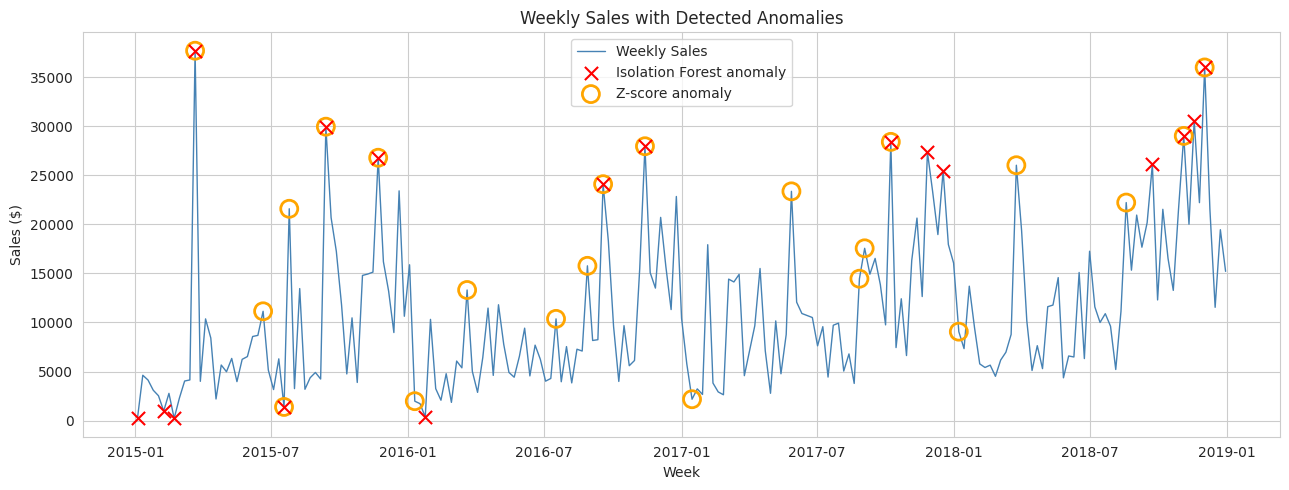

In [ ]:
plt.figure(figsize=(13, 5))
plt.plot(weekly_ts['Week'], weekly_ts['Sales'], color='steelblue', label='Weekly Sales', linewidth=1)
plt.scatter(iso_anomalies['Week'], iso_anomalies['Sales'], color='red', marker='x', s=90,
            label='Isolation Forest anomaly', zorder=5)
plt.scatter(z_anomalies['Week'], z_anomalies['Sales'], facecolors='none', edgecolors='orange',
            s=150, linewidths=2, label='Z-score anomaly', zorder=4)
plt.title('Weekly Sales with Detected Anomalies')
plt.xlabel('Week')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task5_anomalies.png')
plt.show()


### Do the two methods agree?

In [ ]:
iso_weeks = set(iso_anomalies['Week'])
z_weeks = set(z_anomalies['Week'])
agreed_weeks = iso_weeks.intersection(z_weeks)

print("Weeks flagged by BOTH methods:", len(agreed_weeks))
for w in sorted(agreed_weeks):
    print(" -", w.date())


Weeks flagged by BOTH methods: 9
 - 2015-03-22
 - 2015-07-19
 - 2015-09-13
 - 2015-11-22
 - 2016-09-18
 - 2016-11-13
 - 2017-10-08
 - 2018-11-04
 - 2018-12-02


# Task 6 - Product Demand Segmentation using Clustering


### Building features per sub-category

In [ ]:
subcat_total_sales = df.groupby('Sub-Category')['Sales'].sum()

# growth rate: comparing first year (2015) to last year (2018)
yearly_by_subcat = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()
subcat_growth_rate = (yearly_by_subcat[2018] - yearly_by_subcat[2015]) / yearly_by_subcat[2015]

# volatility: how much monthly sales bounce around, using standard deviation
monthly_by_subcat = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='MS')])['Sales'].sum().reset_index()
subcat_volatility = monthly_by_subcat.groupby('Sub-Category')['Sales'].std()

# average order value
subcat_order_count = df.groupby('Sub-Category').size()
subcat_avg_order_value = subcat_total_sales / subcat_order_count

cluster_features = pd.DataFrame({
    'TotalSales': subcat_total_sales,
    'GrowthRate': subcat_growth_rate,
    'Volatility': subcat_volatility,
    'AvgOrderValue': subcat_avg_order_value,
})

# a couple of sub-categories might end up with NaN growth rate if 2015 had 0 sales for them, filling with 0 just in case
cluster_features = cluster_features.fillna(0)
cluster_features


,TotalSales,GrowthRate,Volatility,AvgOrderValue
Sub-Category,,,,
Accessories,164186.7000,1.450560,2579.994809,217.178175
Appliances,104618.4030,1.652429,1821.621539,227.926804
Art,26705.4100,0.496495,330.488343,34.019631
Binders,200028.7850,0.657786,3848.223648,134.067550
Bookcases,113813.1987,0.498466,2220.405080,503.598224
Chairs,322822.7310,0.209547,4407.232960,531.833165
Copiers,146248.0940,4.797295,5500.774391,2215.880212
Envelopes,16128.0460,-0.121213,228.218688,65.032444
Fasteners,3001.9600,0.304684,48.742229,14.027850


### Finding the right number of clusters (Elbow Method)

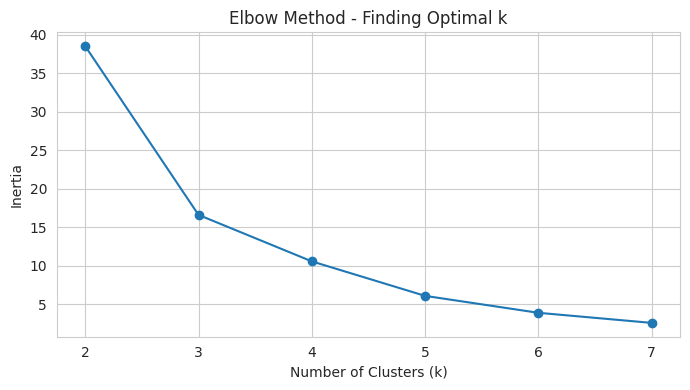

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# scaling first because these 4 features are on totally different scales -
# TotalSales is in the tens of thousands, GrowthRate is a small decimal like 0.5,
# without scaling, TotalSales would basically be the only thing KMeans pays attention to
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

inertia_scores = []
k_options = range(2, 8)
for k in k_options:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia_scores.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_options), inertia_scores, marker='o')
plt.title('Elbow Method - Finding Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('charts/task6_elbow.png')
plt.show()


### Running KMeans with k=4

In [ ]:
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_features['Cluster'] = kmeans_model.fit_predict(scaled_features)

cluster_avg_stats = cluster_features.groupby('Cluster')[['TotalSales', 'GrowthRate', 'Volatility', 'AvgOrderValue']].mean()
cluster_avg_stats


,TotalSales,GrowthRate,Volatility,AvgOrderValue
Cluster,,,,
0,239495.780667,0.564652,3489.056075,361.131228
1,146248.094000,4.797295,5500.774391,2215.880212
2,54341.708189,0.587958,1031.431565,142.746758
3,189238.631000,-0.297931,5603.554747,1645.553313


In [ ]:
cluster_labels = {}
cluster_labels[cluster_avg_stats['TotalSales'].idxmax()] = 'High Volume, Stable Demand'
cluster_labels[cluster_avg_stats['GrowthRate'].idxmax()] = 'Growing Demand'
cluster_labels[cluster_avg_stats['GrowthRate'].idxmin()] = 'Declining Demand'

# anything not labeled yet falls into this bucket
for cluster_num in cluster_avg_stats.index:
    if cluster_num not in cluster_labels:
        cluster_labels[cluster_num] = 'Low Volume, High Volatility'

cluster_features['Label'] = cluster_features['Cluster'].map(cluster_labels)
cluster_features[['TotalSales', 'GrowthRate', 'Volatility', 'AvgOrderValue', 'Cluster', 'Label']].sort_values('Cluster')


,TotalSales,GrowthRate,Volatility,AvgOrderValue,Cluster,Label
Sub-Category,,,,,,
Accessories,164186.7000,1.450560,2579.994809,217.178175,0,"High Volume, Stable Demand"
Binders,200028.7850,0.657786,3848.223648,134.067550,0,"High Volume, Stable Demand"
Chairs,322822.7310,0.209547,4407.232960,531.833165,0,"High Volume, Stable Demand"
Storage,219343.3920,0.383661,2822.084310,263.633885,0,"High Volume, Stable Demand"
Phones,327782.4480,0.355576,4052.718221,374.180877,0,"High Volume, Stable Demand"
Tables,202810.6280,0.330780,3224.082504,645.893720,0,"High Volume, Stable Demand"
Copiers,146248.0940,4.797295,5500.774391,2215.880212,1,Growing Demand
Art,26705.4100,0.496495,330.488343,34.019631,2,"Low Volume, High Volatility"
Envelopes,16128.0460,-0.121213,228.218688,65.032444,2,"Low Volume, High Volatility"


### Visualizing the clusters with PCA

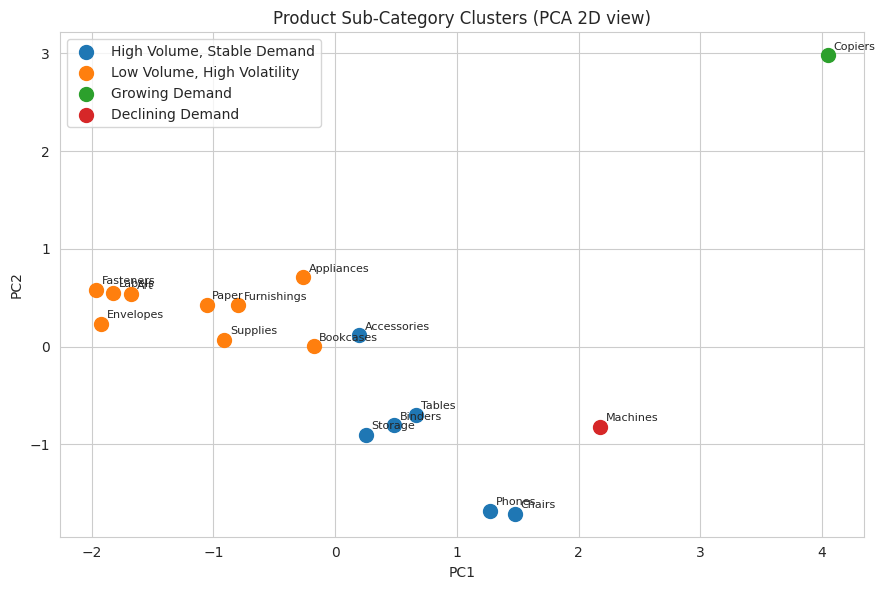

In [ ]:
from sklearn.decomposition import PCA

# we have 4 features but can only really plot in 2D, so PCA compresses
# the 4 dimensions down to the 2 directions that capture the most spread in the data
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_features)
cluster_features['PC1'] = pca_coords[:, 0]
cluster_features['PC2'] = pca_coords[:, 1]

plt.figure(figsize=(9, 6))
for label_name in cluster_features['Label'].unique():
    subset = cluster_features[cluster_features['Label'] == label_name]
    plt.scatter(subset['PC1'], subset['PC2'], label=label_name, s=100)

for subcat_name, row in cluster_features.iterrows():
    plt.annotate(subcat_name, (row['PC1'], row['PC2']), fontsize=8, xytext=(4, 4), textcoords='offset points')

plt.title('Product Sub-Category Clusters (PCA 2D view)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task6_clusters_pca.png')
plt.show()


# Conclusion

Going through all 8 tasks, here's a quick recap of what this project actually found and built:

- **Data-wise**, we've got 4 years of Superstore sales, Technology leads in revenue, East is the most consistently growing region, and there's clear seasonality with Sep/Nov/Dec being reliably strong months every year.
- **Forecasting-wise**, we tried 3 different types of models (SARIMA, Prophet, XGBoost) and compared them properly with MAE/RMSE/MAPE instead of just guessing which one "feels" better. XGBoost technically scored best on this test window, but SARIMA/Prophet are still probably the safer pick for real business use because they come with confidence intervals.
- We also forecasted specific categories/regions instead of just one company-wide number, found some genuine anomaly weeks that line up with real shopping events, and grouped products into 4 sensible demand clusters with different stocking advice for each.
- Finally, all of this got wrapped into a working Streamlit dashboard (Task 7) so someone who isn't a data scientist could actually use these results, plus a plain-English business report (Task 8) for leadership.

**Overall limitation to be upfront about:** everything in this project is based purely on historical sales numbers. We don't have data on things like promotions, competitor actions, weather, or actual inventory/stockout events, all of which could meaningfully affect real-world accuracy. If I were continuing this project, adding those as extra features (especially for the XGBoost model, which can easily take on more inputs) would probably be the single biggest improvement I could make.

This was honestly a pretty big step up from anything I'd built before starting this internship - going from "run a regression on some rows" to an actual end-to-end system with multiple models, proper evaluation, anomaly detection, clustering and a working dashboard was uncomfortable at points but I think that discomfort is what actually made me learn it properly instead of just copying a tutorial.